# Final Project Phase 3 Summary
This Jupyter Notebook (.ipynb) will serve as the skeleton file for your submission for Phase 3 of the Final Project. Complete all sections below as specified in the instructions for the project, covering all necessary details. We will use this to grade your individual code (Do this whether you are in a group or not). Good luck! <br><br>

Note: To edit a Markdown cell, double-click on its text.

## Jupyter Notebook Quick Tips
Here are some quick formatting tips to get you started with Jupyter Notebooks. This is by no means exhaustive, and there are plenty of articles to highlight other things that can be done. We recommend using HTML syntax for Markdown but there is also Markdown syntax that is more streamlined and might be preferable. 
<a href = "https://towardsdatascience.com/markdown-cells-jupyter-notebook-d3bea8416671">Here's an article</a> that goes into more detail. (Double-click on cell to see syntax)

# Heading 1
## Heading 2
### Heading 3
#### Heading 4
<br>
<b>BoldText</b> or <i>ItalicText</i>
<br> <br>
Math Formulas: $x^2 + y^2 = 1$
<br> <br>
Line Breaks are done using br enclosed in < >.
<br><br>
Hyperlinks are done with: <a> https://www.google.com </a> or 
<a href="http://www.google.com">Google</a><br>

# Video Presentation

If you uploaded your Video Presentation to Bluejeans, YouTube, or any other streaming services, please provide the link here:


*   Video Presentation Link: https://youtu.be/KofZXyyUJG0


Make sure the video sharing permissions are accessible for anyone with the provided link.

# Data Collection and Cleaning


Transfer/update the data collection and cleaning you created for Phase II below. You may include additional cleaning functions if you have extra datasets. If no changes are necessary, simply copy and paste your phase II parsing/cleaning functions.


## Downloaded Dataset Requirement



In [52]:
import pandas as pd
def data_parser():
    df = pd.read_csv("Border_Crossing_Entry_Data.csv")
    duplicates = df[df.duplicated(keep = False)]
    print(f"The total number of duplicated rows are {len(duplicates)}.")
    df_cleaned = df.drop_duplicates()
    df_cleaned.to_csv("Cleaned_Border_Crossing_Data.csv")
    return df_cleaned

############ Function Call ############
data_parser()

The total number of duplicated rows are 20.


,Port Name,State,Port Code,Border,Date,Measure,Value,Latitude,Longitude,Point
0,Jackman,Maine,104,US-Canada Border,Jan 2024,Trucks,6556,45.806,-70.397,POINT (-70.396722 45.805661)
1,Porthill,Idaho,3308,US-Canada Border,Apr 2024,Trucks,98,49.000,-116.499,POINT (-116.49925 48.999861)
2,San Luis,Arizona,2608,US-Mexico Border,Apr 2024,Buses,10,32.485,-114.782,POINT (-114.7822222 32.485)
3,Willow Creek,Montana,3325,US-Canada Border,Jan 2024,Pedestrians,2,49.000,-109.731,POINT (-109.731333 48.999972)
4,Warroad,Minnesota,3423,US-Canada Border,Jan 2024,Personal Vehicle Passengers,9266,48.999,-95.377,POINT (-95.376555 48.999)
...,...,...,...,...,...,...,...,...,...,...
403852,Norton,Vermont,211,US-Canada Border,Aug 2025,Truck Containers Loaded,521,45.011,-71.793,POINT (-71.793219 45.010771)
403853,Limestone,Maine,118,US-Canada Border,Aug 2025,Personal Vehicles,907,46.925,-67.790,POINT (-67.789597 46.924555)
403854,Trout River,New York,715,US-Canada Border,Aug 2025,Personal Vehicle Passengers,18646,44.992,-74.308,POINT (-74.308172 44.992058)
403855,El Paso,Texas,2402,US-Mexico Border,Aug 2025,Trains,125,31.764,-106.451,POINT (-106.451188 31.764363)


## Web Collection Requirement \#1


In [53]:
import requests
import pandas as pd 
import numpy as np
import json
    
def web_parser1(url):
    data = requests.get(url).json()
    df = pd.DataFrame(data["data"]["stations"])
    # print("The Original Data:")
    # display(df.head(20))    
    # print("The Number of NaN's BEFORE:", df.isna().sum())

    df.fillna(0, inplace = True)
    # print("The Number of NaN's AFTER:", df.isna().sum())
    df.to_csv("Cleaned_Stations_JSON.csv")
    return df

# ############ Function Call ############
web_parser1("https://gbfs.citibikenyc.com/gbfs/en/station_status.json")


,is_installed,eightd_has_available_keys,last_reported,num_bikes_available,num_docks_disabled,is_returning,num_bikes_disabled,is_renting,station_id,legacy_id,num_ebikes_available,num_docks_available,num_scooters_available,num_scooters_unavailable
0,0,False,1760963237,0,0,0,0,0,2c8b263e-952c-4941-a671-ef0ebb062632,5048,0,0,0.0,0.0
1,0,False,86400,0,0,0,0,0,2124426307973079924,2124426307973079924,0,0,0.0,0.0
2,0,False,1759854204,0,0,0,0,0,55a4dc76-d839-4e06-9bf4-2f343391343c,3888,0,0,0.0,0.0
3,0,False,86400,0,0,0,0,0,1905837242740508940,1905837242740508940,0,0,0.0,0.0
4,0,False,1756815971,0,0,0,0,0,a47f77a2-9008-4652-a4f1-b95eee723a1b,3712,0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305,1,False,1764026450,9,0,1,4,1,2088688422524183306,2088688422524183306,3,26,0.0,0.0
2306,1,False,1764026446,19,0,1,2,1,66dd5a42-0aca-11e7-82f6-3863bb44ef7c,3187,18,1,0.0,0.0
2307,1,False,1764026399,8,0,1,3,1,66dddd28-0aca-11e7-82f6-3863bb44ef7c,3277,3,3,0.0,0.0
2308,1,False,1764026501,14,0,1,0,1,66dddc08-0aca-11e7-82f6-3863bb44ef7c,3275,6,0,0.0,0.0


## Web Collection Requirement #2

In [54]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

def web_parser2(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text)

    table = soup.find("table")
    all_rows = table.find_all("tr")
    data = []
    for row in all_rows:
        cells = row.find_all(['th', 'td'])
        cell_values = [cell.get_text(strip = True) for cell in cells]
        data.append(cell_values)
        
    header = data[0]
    subheader = data[1]
    subheader.insert(0,"STATE")
    rows = data[2:]

    wanted_column = 11
    number_values = []
    for row in rows:
        value = row[wanted_column]
        if value.strip() != "—":
            clean_value = value.replace (",", "")
            if clean_value.isdigit():
                number_values.append(int(clean_value))
    average = sum(number_values) // len(number_values)
    
    for row in rows:
        if row[wanted_column].strip()== "—":
            row[wanted_column] = average

    final = [header, subheader] + rows
    df = pd.DataFrame(final)
    df.to_csv("cleaned_web2.csv")
    return df

############ Function Call ############
web_parser2("https://www.fhwa.dot.gov/policyinformation/statistics/2022/mv1.cfm#foot2")

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,STATE,AUTOMOBILES,BUSES,TRUCKS,MOTORCYCLES,ALL MOTOR VEHICLES,None,None,None,None,None,None,None,None,None,None
1,STATE,PRIVATE ANDCOMMERCIAL(INCLUDINGTAXICABS),PUBLICLY OWNED,TOTAL,PRIVATE AND COMMERCIAL,PUBLICLY OWNED,TOTAL,PRIVATE AND COMMERCIAL,PUBLICLY OWNED,TOTAL,PRIVATE AND COMMERCIAL,PUBLICLY OWNED,TOTAL,PRIVATE AND COMMERCIAL,PUBLICLY OWNED,TOTAL
2,Alaska,"132,017","2,282","134,299","7,883",579,"8,462","498,305","12,421","510,726","25,627",11,"25,638","663,832","15,293","679,125"
3,Arizona,"2,168,310","32,496","2,200,806","4,486","16,878","21,364","3,524,206","64,693","3,588,899","277,787","1,323","279,110","5,974,789","115,390","6,090,179"
4,Arkansas (2),"910,969","17,987","928,956","10,017",823,"10,840","2,132,989","45,167","2,178,156","98,364",1598,"98,364","3,152,339","63,977","3,216,316"
5,California,"13,558,261","237,848","13,796,109","28,802","67,163","95,965","16,092,736","331,803","16,424,539","789,100","13,400","802,500","30,468,899","650,214","31,119,113"
6,Colorado,"1,426,578","15,359","1,441,937","5,062","7,815","12,877","3,437,012","44,929","3,481,941","180,103",1598,"180,103","5,048,755","68,103","5,116,858"
7,Connecticut (2),"1,100,313",420,"1,100,733","9,951",24,"9,975","1,589,239","4,600","1,593,839","84,876",1598,"84,876","2,784,379","5,044","2,789,423"
8,Delaware,"168,037","2,011","170,048","2,107","1,330","3,437","264,749","4,427","269,176","24,533",74,"24,607","459,426","7,842","467,268"
9,Dist. of Col.,"188,795","12,412","201,207",761,"5,876","6,637","152,531","15,881","168,412","4,201",344,"4,545","346,288","34,513","380,801"


#Inconsistency Revisions
 **If you were requested to revise your inconsistency section from Phase II, enter your responses here. Otherwise, ignore this section.**

For each inconsistency (NaN, null, duplicate values, empty strings, etc.) you discover in your datasets, write at least 2 sentences stating the significance, how you identified it, and how you handled it.

1. 

2. 

3. 

4. (if applicable)

5. (if applicable)


## Data Sources

Include sources (as links) to your datasets. If any of these are different from your sources used in Phase II, please <b>clearly</b> specify.

*   Downloaded Dataset Source: https://catalog.data.gov/dataset/border-crossing-entry-data-683ae
*   Web Collection #1 Source: https://gbfs.citibikenyc.com/gbfs/en/station_status.json
*   Web Collection #2 Source: https://www.fhwa.dot.gov/policyinformation/statistics/2022/mv1.cfm#foot2



# Data Analysis
For the Data Analysis section, you are required to utilize your data to complete the following:

*   Create at least 5 insights
*   Generate at least 3 data visualizations

Create a function for each of the following sections mentioned above. Do not forget to fill out the explanation section for each function. 

Make sure your data analysis is not too simple. Performing complex aggregation and using modules not taught in class shows effort, which will increase the chance of receiving full credit. 

# Topic Summary

Please provide a brief executive summary (5 sentences or less) discussing your topic:

This project explores how different transportation patterns across the United States relate to border activity, state vehicle counts, and pedestrian movement. By using multiple cleaned datasets, I analyzed trends through linear regression, clustering, ratios and aggregated summaries. The insights show how strongly border crossings are related to truck numbers, how states group based on their vehicle volume, how NYC's bike availability comapres to national pedestrian movement, and how trucks to automobile ratio vary across states. The visualizations help to highlight these relationships clearly and make the findings easier to compare and see their significance. Overall, the project shows how transportation data can uncover meaningful differences in infrasctucture is used across different regions in the United States.

## Insights

### Insight 1 Explanation

This insight explores whether states with high truck columes also experience higher total border crossings. I combined the border-crossing dataset with eeach state's truck counts and ran a linear regression to see how strongly trucks predict total crossings. The merged dataset shows both actual and predicted values. This analysis matters because it helps determine whether truck activity can be used as an indicator of overall border movement intensity.

In [55]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.pyplot as plt


def insight1():
    border_df = pd.read_csv("Cleaned_Border_Crossing_Data.csv")
    vehicles_df = pd.read_csv("cleaned_web2.csv")

    vehicles_data = vehicles_df.iloc[2:, :]
    # print(vehicles_data)
    state_col = vehicles_data.iloc[:, 1]
    trucks_col = vehicles_data.iloc[:, 9]

    vehicles_clean = pd.DataFrame({"STATE": state_col, "TRUCKS": trucks_col})
    vehicles_clean["TRUCKS"] = (vehicles_clean["TRUCKS"].astype(str).str.replace(",", "").astype(float))
    border_state = (border_df.groupby("State")["Value"].sum().reset_index().rename(columns={"Value": "Total Crossings"}))

    merged = border_state.merge(vehicles_clean, left_on="State", right_on="STATE", how="inner")
    # print(merged)
    X = merged[["Total Crossings"]]
    y = merged["TRUCKS"]

    model = LinearRegression()
    model.fit(X, y)
    predictions = model.predict(X)

    merged["Predicted"] = predictions
    return (merged.head(10))

############ Function Call ############
insight1()

,State,Total Crossings,STATE,TRUCKS,Predicted
0,Alaska,17063383,Alaska,12421.0,17186.184268
1,Arizona,1083658832,Arizona,64693.0,90170.284515
2,California,3114193968,California,331803.0,229114.042488
3,Maine,254949557,Maine,4566.0,33464.060183
4,Michigan,859120504,Michigan,97987.0,74805.763829
5,Montana,63646920,Montana,5837.0,20373.763530
6,New Mexico,88384991,New Mexico,46283.0,22066.519538
7,North Dakota,90933920,North Dakota,15778.0,22240.935517
8,Texas,4364463603,Texas,244720.0,314666.446132


In [56]:
def insight2():
    df = pd.read_csv("cleaned_web2.csv")
    df2 = df.iloc[2:, :]
    states = df2.iloc[:, 1]
    auto = df2.iloc[:, 3].astype(str).str.replace(",", "").astype(float)
    trucks = df2.iloc[:, 9].astype(str).str.replace(",", "").astype(float)

    X = np.column_stack([auto, trucks])
    k = 3
    rng = np.random.RandomState(42)
    initial_centroids = rng.permutation(X.shape[0])[:k]
    centroids = X[initial_centroids]
    for i in range(5):
        labels = pairwise_distances_argmin(X, centroids)
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        centroids = new_centroids
    
    result = pd.DataFrame({"State": states, "Autos": auto, "Trucks": trucks, "Cluster": labels})
    return result.head(10)
    
############ Function Call ############
insight2()

,State,Autos,Trucks,Cluster
2,Alaska,2282.0,12421.0,1
3,Arizona,32496.0,64693.0,1
4,Arkansas (2),17987.0,45167.0,1
5,California,237848.0,331803.0,0
6,Colorado,15359.0,44929.0,1
7,Connecticut (2),420.0,4600.0,1
8,Delaware,2011.0,4427.0,1
9,Dist. of Col.,12412.0,15881.0,1
10,Florida,98807.0,163565.0,0
11,Georgia,51490.0,93384.0,0


### Insight 2 Explanation

This insight groups states into clusters based on their number of automobiles and trucks. Using a manual k-means clustering process, states are seperated into three groups representing low, medium, and high vehicle volumes. This is usedul because it identifies patterns in transportation density and helps compare states with similar traffic levels.

In [57]:
def insight3():
    json_df = pd.read_csv("Cleaned_Stations_JSON.csv")
    border_df = pd.read_csv("Cleaned_Border_Crossing_Data.csv")
    total_city_bikes = json_df["num_bikes_available"].sum()
    avg_bikes_station = json_df["num_bikes_available"].mean()

    pedestrian_df = border_df[border_df["Measure"].str.contains("Pedestrian")]
    total_pedestrian_crossings = pedestrian_df["Value"].sum()

    final = pd.DataFrame({"Total NYC Bikes": [total_city_bikes], "Average Bikes / Station": avg_bikes_station, 
                          "Total Border Pedestrian Crossings": total_pedestrian_crossings})
    return final

############ Function Call ############
insight3()

,Total NYC Bikes,Average Bikes / Station,Total Border Pedestrian Crossings
0,28651,12.40303,1279319340


### Insight 3 Explanation

This insight compares the scale of New York's bike sharing system with nationwide pedestrian border crossings. I calculated the total number of NYC bikes, the average bikes per station, and summed all pedestrian border crossings across the country. This provides a perspective on the difference between city level transportation usage and large scale pedestrian movement nation wide.

In [58]:
def insight4():
    df = pd.read_csv("cleaned_web2.csv")
    df2 = df.iloc[2:, :]
    states = df2.iloc[:, 1].values
    autos = df2.iloc[:, 3].astype(str).str.replace(",", "").astype(float)
    trucks = df2.iloc[:, 9].astype(str).str.replace(",", "").astype(float)
    ratio = trucks / autos

    final = pd.DataFrame({ "State": states, "Automobiles": autos, "Trucks": trucks, 
                          "Truck-to-Auto Ratio": ratio})
    final_sorted = final.sort_values("Truck-to-Auto Ratio", ascending = False)
    return final_sorted.head(10)

############ Function Call ############
insight4()

,State,Automobiles,Trucks,Truck-to-Auto Ratio
27,Montana,409.0,5837.0,14.271394
51,Wyoming,383.0,4211.0,10.994778
7,Connecticut (2),420.0,4600.0,10.952381
26,Missouri (2),1303.0,9276.0,7.118956
13,Idaho (3),1073.0,7358.0,6.857409
15,Indiana,1590.0,8863.0,5.574214
2,Alaska,2282.0,12421.0,5.443032
14,Illinois,4357.0,20023.0,4.595593
35,North Dakota,3881.0,15778.0,4.065447
25,Mississippi,1832.0,6982.0,3.811135


### Insight 4 Explanation

This insight compares how many trucks each state has relative to the number of automobiles. After cleaning the dataset, I calculated a “truck-to-auto ratio” for every state and sorted them from highest to lowest. A higher ratio means the state relies more on trucks, which can show heavier freight movement or fewer personal cars. This helps us see which states have the strongest trucking activity.

In [59]:
def insight5():
    df = pd.read_csv("Cleaned_Border_Crossing_Data.csv")
    final = (df.groupby("Measure")["Value"].sum().reset_index())
    return final

############ Function Call ############
insight5()

,Measure,Value
0,Bus Passengers,159104259
1,Buses,9497334
2,Pedestrians,1279319340
3,Personal Vehicle Passengers,6422158650
4,Personal Vehicles,3101221460
5,Rail Containers Empty,30126103
6,Rail Containers Loaded,52334100
7,Train Passengers,7426524
8,Trains,1105184
9,Truck Containers Empty,86885378


### Insight 5 Explanation

This insight shows which border-crossing types have the highest total activity. I grouped the data by crossing type (like pedestrians, personal vehicles, buses, trains, etc.) and added up the total crossings for each one. This helps reveal which types are used the most and gives a clear picture of how people and goods move across U.S. borders.

## Data Visualizations

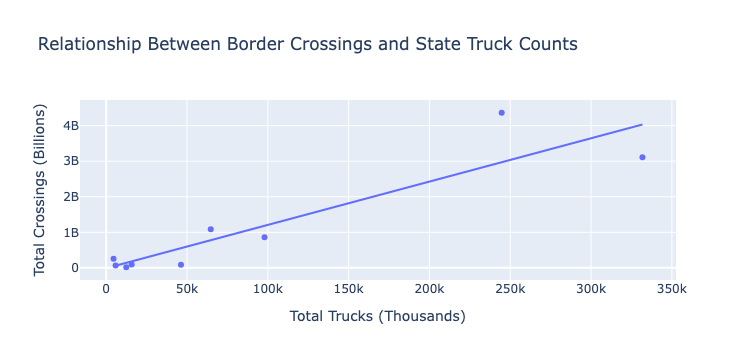

In [60]:
import plotly.express as px
def visual1():
    df = insight1()
    fig = px.scatter(df, x = "TRUCKS", y = "Total Crossings", trendline = "ols", 
                     title = "Relationship Between Border Crossings and State Truck Counts",
                     labels = {"TRUCKS": "Total Trucks (Thousands)", "Total Crossings": "Total Crossings (Billions)"})
    fig.show()

############ Function Call ############
visual1()

### Visualization 1 Explanation

This scatter plot shows the relationship between how many trucks a state has and how many border crossings it experiences. Each point is a state, and the trendline helps us see the overall pattern. States with more trucks generally have more total crossings, meaning truck activity is connected to border movement.

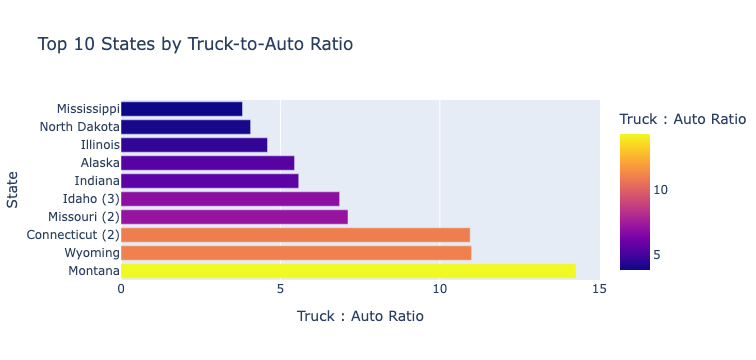

In [61]:
def visual2():
    df = insight4()
    fig = px.bar(df, x = "Truck-to-Auto Ratio", y = "State", orientation = "h", title = "Top 10 States by Truck-to-Auto Ratio",
        labels = {"Truck-to-Auto Ratio": "Truck : Auto Ratio"}, color = "Truck-to-Auto Ratio")
    fig.show()

############ Function Call ############
visual2()

### Visualization 2 Explanation

This horizontal bar chart shows the top 10 states with the highest truck-to-auto ratio. Longer bars mean the state relies more on trucks compared to personal vehicles. This makes it easy to compare which states have stronger trucking activity.

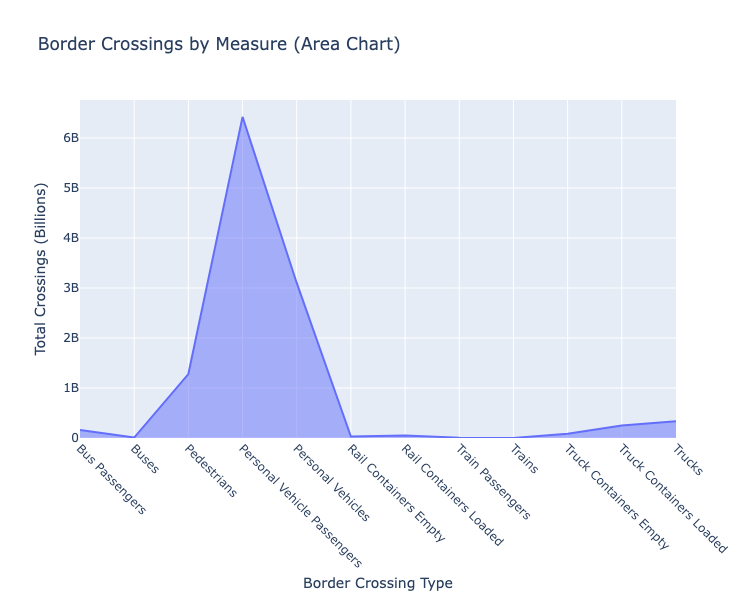

In [62]:
def visual3():
    df = insight5()
    fig = px.area(df, x = "Measure", y = "Value", title = "Border Crossings by Measure (Area Chart)",
        labels = {"Measure": "Border Crossing Type", "Value": "Total Crossings (Billions)"},)
    fig.update_layout(xaxis_tickangle = 45, height = 600)
    fig.show()

############ Function Call ############
visual3()

### Visualization 3 Explanation

This area chart shows the total number of border crossings for each crossing type. The size of the shaded area reflects how frequently each mode is used. It quickly highlights which crossing types handle the most traffic—like personal vehicles and pedestrians—compared to smaller categories.

# Cited Sources

If you used any additional sources to complete your Data Analysis section, list them here:


*   Example Module Documentation
*   Example Stack Overflow Assistance



# Graphical User Interface (GUI) Implementation
If you decide to create a GUI for Phase II, please create a separate Python file (.py) to build your GUI. You must submit both the completed PhaseII.ipynb and your Python GUI file.

#Submission

Prior to submitting your notebook to Gradescope, be sure to <b>run all functions within this file</b>. We will not run your functions ourselves, so we must see your outputs within this file in order to receive full credit.
